In [1]:
# !pip uninstall tensorflow -y
# # !pip install tensorflow

# !pip install --upgrade pip
# !pip install tensorflow[and-cuda]

In [1]:
!nvidia-smi

Mon Mar 23 21:57:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.02              Driver Version: 560.94         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...    On  |   00000000:01:00.0  On |                  N/A |
| N/A   52C    P8              7W /   43W |    1590MiB /   8188MiB |     25%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import tensorflow as tf

tf.config.list_physical_devices("GPU")

I0000 00:00:1774283271.869999  104829 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774283271.921173  104829 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774283273.357255  104829 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1774283274.103894  104829 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries men

[]

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [11]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

t_1_dl_gen_ainppe_1_path = kagglehub.competition_download('26-t-1-dl-gen-ainppe-1')

print('Data source import complete.')


100%|██████████| 7.89G/7.89G [00:46<00:00, 181MB/s]

Extracting files...


Data source import complete.


In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for name in os.listdir('/root/.cache/kagglehub/competitions/26-t-1-dl-gen-ainppe-1'):
    if name.endswith('.csv'):
        print(os.path.join('/root/.cache/kagglehub/competitions/26-t-1-dl-gen-ainppe-1', name))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/root/.cache/kagglehub/competitions/26-t-1-dl-gen-ainppe-1/train.csv
/root/.cache/kagglehub/competitions/26-t-1-dl-gen-ainppe-1/test.csv
/root/.cache/kagglehub/competitions/26-t-1-dl-gen-ainppe-1/sample_submission.csv


## Automated Detection of Thoracic Pathologies from Chest X-ray Images

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
import math

In [14]:
train_df= pd.read_csv("/root/.cache/kagglehub/competitions/26-t-1-dl-gen-ainppe-1/train.csv")
test_df= pd.read_csv("/root/.cache/kagglehub/competitions/26-t-1-dl-gen-ainppe-1/test.csv")

In [15]:
print(f"shape of training datasets is:{train_df.shape}")
print(f"shape of training datasets is:{test_df.shape}")

shape of training datasets is:(51043, 21)
shape of training datasets is:(17015, 1)


In [16]:
suggest_output= pd.read_csv("/root/.cache/kagglehub/competitions/26-t-1-dl-gen-ainppe-1/sample_submission.csv")
suggest_output.head()

,id,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Pneumoperitoneum,Pneumomediastinum,Subcutaneous Emphysema,Tortuous Aorta,Calcification of the Aorta,No Finding
0,7b647fbfcc874a7084a4470fc150e267.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,cc804b94d80c4a80a206298c307adfec.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1df09c3becd04de995244caae36ddf57.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,044cac47cfdf4c8b90848c9e56c36bfa.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,a873523c43664a049c5e8f26add7ecb2.png,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [17]:
train_df.iloc[:,1:].sum(axis=0).sort_values(ascending=False)

,0
No Finding,34079
Infiltration,5206
Atelectasis,2351
Effusion,2156
Nodule,1527
Mass,1249
Pneumothorax,1114
Consolidation,651
Pleural_Thickening,608
Cardiomegaly,600


In [18]:
image_path="/root/.cache/kagglehub/competitions/26-t-1-dl-gen-ainppe-1/images/"

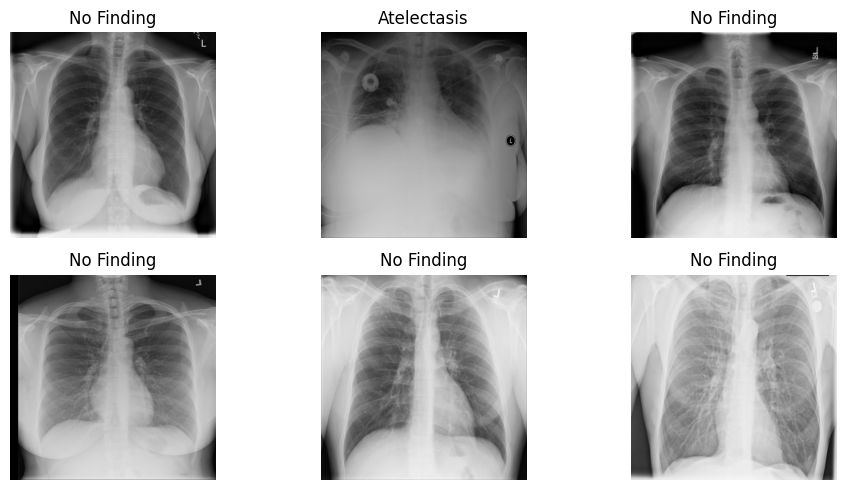

In [19]:
plt.figure(figsize=(10,5))

for i in range(1, 7):
    image_name= train_df.iloc[i,0]
    label_series= train_df.iloc[i,1:]
    label= label_series[label_series==1].index.tolist()[0]
    image_com_path= image_path+ image_name
    img= Image.open(image_com_path) # image mode=RGB size=384x384


    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")


plt.tight_layout()  # adjusts spacing
plt.show()

In [20]:
# Generator
class DataGenerator(Sequence):
    def __init__(self, df, image_path, batch_size=32):
        self.df=df
        self.image_path= image_path
        self.batch_size=batch_size
    def __len__(self):
        return len(self.df)//self.batch_size

    def __getitem__(self, idx):
        batch= self.df.iloc[idx*self.batch_size:(idx+1)*self.batch_size, :]

        X, y= [], []
        for _, row in batch.iterrows():
            img= Image.open(self.image_path+row.iloc[0])
            img= img.resize((224, 224))
            img= np.array(img)/255.0

            X.append(img)
            y.append(row.iloc[1:].to_numpy(dtype='float32')) # .values does NOT guarantee numeric dtype

        return np.array(X), np.array(y)







train_gen= DataGenerator(train_df, image_path=image_path, batch_size=94)

X_, y_= train_gen[0]



## Data Augmentation

In [21]:
AUGMENT_MULTIPLIER = {
    'No Finding'                : 0,   # already 34k — no augmentation
    'Infiltration'              : 0,   # 5206 — enough
    'Atelectasis'               : 2,   # 2351 → ~4700
    'Effusion'                  : 2,   # 2156 → ~4300
    'Nodule'                    : 3,   # 1527 → ~4500
    'Mass'                      : 3,   # 1249 → ~3750
    'Pneumothorax'              : 4,   # 1114 → ~4456
    'Consolidation'             : 5,   # 651  → ~3255
    'Pleural_Thickening'        : 5,   # 608  → ~3040
    'Cardiomegaly'              : 5,   # 600  → ~3000
    'Fibrosis'                  : 8,   # 389  → ~3112
    'Edema'                     : 8,   # 326  → ~2608
    'Tortuous Aorta'            : 10,  # 254  → ~2540
    'Emphysema'                 : 15,  # 172  → ~2580
    'Pneumonia'                 : 15,  # 160  → ~2400
    'Calcification of the Aorta': 25,  # 91   → ~2275
    'Pneumoperitoneum'          : 40,  # 44   → ~1760
    'Hernia'                    : 40,  # 37   → ~1480
    'Subcutaneous Emphysema'    : 60,  # 24   → ~1440
    'Pneumomediastinum'         : 80,  # 5    → ~400
}


def build_augmented_dataframe(train_df, multipliers):
    """
    For each rare class, find its images and
    create extra copies (augmentation happens in generator).
    """
    augmented_rows = [train_df]  # start with original data

    for class_name, multiplier in multipliers.items():
        if multiplier == 0:
            continue

        # Find images that have this disease
        class_rows = train_df[train_df[class_name] == 1]
        print(f"{class_name:<35} {len(class_rows)} original "
              f"→ {len(class_rows) * multiplier} augmented copies")

        # Add copies — generator will apply different random augmentation
        # each time it loads these rows

        for _ in range(multiplier):
            augmented_rows.append(class_rows)

    result = pd.concat(augmented_rows, ignore_index=True)
    result = result.sample(frac=1, random_state=42)  # shuffle
    print(f"\nTotal rows: {len(train_df)} → {len(result)}")
    return result


# Build augmented training dataframe
train_df_aug = build_augmented_dataframe(
    train_df, AUGMENT_MULTIPLIER
)




class DataAugmentGenerator(Sequence):
    def __init__(self, df, image_path, batch_size=32):
        self.df=df
        self.image_path= image_path
        self.batch_size=batch_size

    def __len__(self):
        return math.ceil(len(self.df)/self.batch_size)

    def __augment(self, img):
      """ Apply safe medical augmentation. """

      # Horizontal flip (50% chance) — anatomically valid
      if np.random.rand() > 0.5:
          img = np.fliplr(img)

      # Small rotation ±10 degrees
      if np.random.rand() > 0.5:
          angle  = np.random.uniform(-10, 10)
          h, w   = img.shape[:2]
          matrix = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
          img    = cv2.warpAffine(
              img, matrix, (w, h),
              borderMode=cv2.BORDER_REFLECT
          )

      # Brightness shift ±20%
      if np.random.rand() > 0.5:
          factor = np.random.uniform(0.8, 1.2)
          img    = np.clip(img * factor, 0, 1)

      # Contrast shift
      if np.random.rand() > 0.5:
          mean   = img.mean()
          factor = np.random.uniform(0.8, 1.2)
          img    = np.clip((img - mean) * factor + mean, 0, 1)

      # Gaussian noise — simulate detector noise
      if np.random.rand() > 0.5:
          noise = np.random.normal(0, 0.01, img.shape).astype(np.float32)
          img   = np.clip(img + noise, 0, 1)

      return img.astype(np.float32)


    def __getitem__(self, idx):
        batch= self.df.iloc[idx*self.batch_size:(idx+1)*self.batch_size,:]

        images, labels=[], []
        for _, row in batch.iterrows():
          img= image.load_img(os.path.join(self.image_path, row.iloc[0]))
          img= img.resize((224, 224))
          img= np.array(img)/255.0

          img = self.__augment(img)
          images.append(img)
          labels.append(row.iloc[1:].to_numpy(dtype="int"))

        # MUST return (numpy_array, numpy_array) — nothing else
        return np.array(images), np.array(labels)

    def on_epoch_end(self):
        # Shuffle data after every epoch so batches are different each time
        self.df = self.df.sample(frac=1).reset_index(drop=True)

train_gen_with_aug= DataAugmentGenerator(train_df_aug, image_path, 94)


Atelectasis                         2351 original → 4702 augmented copies
Effusion                            2156 original → 4312 augmented copies
Nodule                              1527 original → 4581 augmented copies
Mass                                1249 original → 3747 augmented copies
Pneumothorax                        1114 original → 4456 augmented copies
Consolidation                       651 original → 3255 augmented copies
Pleural_Thickening                  608 original → 3040 augmented copies
Cardiomegaly                        600 original → 3000 augmented copies
Fibrosis                            389 original → 3112 augmented copies
Edema                               326 original → 2608 augmented copies
Tortuous Aorta                      254 original → 2540 augmented copies
Emphysema                           172 original → 2580 augmented copies
Pneumonia                           160 original → 2400 augmented copies
Calcification of the Aorta          91 origina

In [22]:
print(X_.dtype)
print(y_.dtype)

print(X_.shape)
print(y_.shape)

float64
float32
(94, 224, 224, 3)
(94, 20)


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow import keras
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D
from keras.optimizers import Adam

from keras.applications import DenseNet121
from keras.optimizers import AdamW


In [24]:
# model= Sequential()

# model.add(Conv2D(32, kernel_size=(3,3), padding="valid",activation='relu', input_shape=(224,224,3)))
# model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))
# # model.add(Conv2D(128, kernel_size=(3,3), padding='valid', activation='relu'))
# # model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

# model.add(Flatten())
# # model.add(Dense(128, activation='relu'))
# model.add(Dense(84, activation='relu'))
# model.add(Dense(20, activation='softmax'))

# model.summary()

In [25]:
# adam= Adam(learning_rate=0.01)

# model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])

# history= model.fit(train_gen, epochs=10)

In [26]:
# plt.plot(history.history['accuracy'], label='Train Accuracy')

# plt.xlabel("Epochs")
# plt.ylabel("Accuracy")

# plt.legend()
# plt.show()

In [27]:
# plt.plot(history.history['loss'], label='Train Loss')

# plt.xlabel("Epochs")
# plt.ylabel("Loss")

# plt.legend()
# plt.show()

In [28]:
test_df.shape

(17015, 1)

## Transfer Learning (Fine-Tuning):

In [29]:
counts= train_df.iloc[:,1:].sum().sort_values(ascending=False).values
class_names= np.array(train_df.iloc[:,1:].sum().sort_values(ascending=False).index).astype('str')

total= train_df.iloc[:,1:].sum().sum()

# pos_weight: how much to boost the positive (disease present) signal
# rare class → very few positives → needs very high weight
pos_weights= (total-counts)/counts # # negative/positive ratio per class

print("Positive weights per class:")
for name, w in zip(class_names, pos_weights):
    print(f"{name:<35} {w:.1f}x")

# option-1 ; weighted bce

def weighted_bce(pos_weights):
    pos_w= tf.constant(pos_weights, dtype=tf.float32)

    def loss(y_true, y_pred):
        # Clip predictions to avoid log(0) which gives infinity
        y_pred= tf.clip_by_value(y_pred, 1e-7, 1- 1e-7)

        # Standard BCE formula but with pos_weight multiplied on positive terms
        # When y_true=1 (disease present): loss is amplified by pos_weight
        # When y_true=0 (disease absent):  loss is normal
        bce = -(
            pos_w * y_true * tf.math.log(y_pred) +          # positive term
            (1 - y_true) * tf.math.log(1 - y_pred)          # negative term
        )
        return tf.reduce_mean(bce)

    return loss

bce_loss_fn= weighted_bce(pos_weights)


## Option 2 — Focal Loss (best for extreme imbalance)
# Focal loss solves a different problem:
# Easy examples (No Finding, very common) → model is already confident → low loss
# Hard examples (Pneumomediastinum, 5 samples) → model is uncertain → high loss
# gamma controls how much to down-weight easy examples
# alpha controls class balance (same as pos_weight above)

def focal_loss(pos_weights, gamma=2.0):
    pos_w= tf.constant(pos_weights, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        # p_t = probability of the TRUE class
        # if disease present (y_true=1): p_t = y_pred
        # if disease absent  (y_true=0): p_t = 1 - y_pred
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)

        # (1 - p_t)^gamma is the "focusing factor"
        # when model is confident (p_t close to 1): factor ≈ 0 → low loss
        # when model is uncertain (p_t close to 0): factor ≈ 1 → high loss
        focal_factor = tf.pow(1 - p_t, gamma)

        # Apply class balance weights on top
        alpha_t = y_true * pos_w + (1 - y_true) * 1.0

        bce = -(
            y_true * tf.math.log(y_pred) +
            (1 - y_true) * tf.math.log(1 - y_pred)
        )

        focal = alpha_t * focal_factor * bce
        return tf.reduce_mean(focal)

    return loss

focal_loss_fn = focal_loss(pos_weights, gamma=2.0)



# Option 3 — Asymmetric Loss (best match for YOUR competition metric)
"""
This is the most important one for our case. our competition penalises FN (missed disease) 5 times as much as FP (false alarm).
our loss function should reflect that exact same asymmetry:
"""

def asymmetric_loss(pos_weights, gamma_neg=4.0, gamma_pos=1.0):
    """
    Different focusing for positives vs negatives:

    gamma_pos=1 → mild focusing on hard positive examples (disease present)
    gamma_neg=4 → aggressive focusing on hard negative examples (no disease)

    This means:
    - Easy negatives (No Finding, model correctly says 0) -> almost ignored
    - Hard positives (rare disease, model misses it)      -> heavily penalised

    Perfectly matches our competition: FN costs 2x more than FP
    """
    pos_w = tf.constant(pos_weights, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        # ── Positive part (disease IS present, y_true=1) ──────────
        pos_loss = y_true * (
            pos_w *
            tf.pow(1 - y_pred, gamma_pos) *   # mild focusing
            tf.math.log(y_pred)
        )

        # ── Negative part (disease NOT present, y_true=0) ─────────
        # Shift prediction by margin to avoid penalising easy negatives
        y_pred_neg = tf.clip_by_value(y_pred, 1e-7, 0.999)
        neg_loss = (1 - y_true) * (
            tf.pow(y_pred_neg, gamma_neg) *   # aggressive focusing
            tf.math.log(1 - y_pred_neg)
        )

        loss_val = -tf.reduce_mean(pos_loss + neg_loss)
        return loss_val

    return loss

# gamma_neg > gamma_pos means we down-weight easy negatives MORE
# which forces the model to focus on rare positive cases
asymmetric_loss_fn = asymmetric_loss(pos_weights, gamma_neg=4.0, gamma_pos=1.0)








Positive weights per class:
No Finding                          0.5x
Infiltration                        8.8x
Atelectasis                         20.7x
Effusion                            22.7x
Nodule                              32.4x
Mass                                39.9x
Pneumothorax                        44.8x
Consolidation                       77.4x
Pleural_Thickening                  83.0x
Cardiomegaly                        84.1x
Fibrosis                            130.2x
Edema                               155.6x
Tortuous Aorta                      200.0x
Emphysema                           295.8x
Pneumonia                           318.0x
Calcification of the Aorta          559.9x
Pneumoperitoneum                    1159.1x
Hernia                              1378.5x
Subcutaneous Emphysema              2125.8x
Pneumomediastinum                   10207.6x


### gamma=0 → focal loss becomes plain BCE (no focusing at all)
### gamma=1 → mild focusing (good starting point)
### gamma=2 → standard focal loss (most common in papers)
### gamma=4 → aggressive (good for your extreme imbalance)
### gamma>5 → usually too aggressive, training becomes unstable

## For our dataset recommend starting with:
gamma_pos = 1.0   # mild on positives — don't over-penalise false negatives
gamma_neg = 4.0   # aggressive on negatives — ignore easy No Finding predictions

### After first training run, if model still misses rare classes → increase gamma_neg to 5
### If training becomes unstable (loss goes to NaN)            → decrease gamma_neg to 3

Multi-class:  one image → exactly ONE disease (mutually exclusive)
              e.g. cat OR dog OR bird

Multi-label:  one image → CAN HAVE multiple diseases simultaneously  
              e.g. Atelectasis=1, Effusion=1, Nodule=0, ...

Your data is multi-label because one X-ray can show Atelectasis AND Effusion AND Cardiomegaly at the same time. So multi_label=True is correct. At keras.metrics.AUC()

In [30]:
from tensorflow.keras.applications.vgg16 import VGG16

In [31]:
conv_base= VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224, 3)
)

conv_base.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
conv_base.trainable=True

set_trainable=False

for layer in conv_base.layers:
    if layer.name=="block5_conv1":
        set_trainable=True
    if set_trainable:
        layer.trainable=True
    else:
        layer.trainable=False
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [33]:
model1= Sequential()

model1.add(conv_base)
model1.add(Flatten())


model1.add(Dense(128, activation='relu'))
model1.add(Dense(84, activation='relu'))
model1.add(Dense(20, activation='softmax'))

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,836 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │         1,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,938,616 (68.43 MB)

 Trainable params: 10,303,352 (39.30 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [34]:
# adamW= AdamW(learning_rate=1e-3, weight_decay=1e-4)

# model1.compile(loss=asymmetric_loss_fn, optimizer=adamW , metrics=[keras.metrics.AUC(multi_label=True, name="auc")])

# history2= model1.fit(train_gen, epochs=11)

In [35]:
# plt.plot(history2.history['accuracy'], label='Train Accuracy')

# plt.xlabel("Epochs")
# plt.ylabel("Accuracy")

# plt.legend()
# plt.show()

In [36]:
# plt.plot(history2.history['loss'], label='Train Loss')

# plt.xlabel("Epochs")
# plt.ylabel("Loss")

# plt.legend()
# plt.show()

In [37]:
conv_base_denseNet= DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224, 3)

)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [38]:
conv_base_denseNet.trainable=True

set_trainable=False

for layer in conv_base_denseNet.layers:
    if layer=="conv5_block15_2_conv":
        set_trainable=True

    if set_trainable:
        layer.trainable=True
    else:
        layer.trainable=False



In [39]:
model2= Sequential()

model2.add(conv_base_denseNet)

model2.add(GlobalAveragePooling2D())
model2.add(Dense(512, activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(128, activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(20, activation='sigmoid'))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,630,548 (29.11 MB)

 Trainable params: 593,044 (2.26 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
adamW= AdamW(learning_rate=1e-3, weight_decay=1e-4)

model2.compile(loss= asymmetric_loss_fn, optimizer=adamW, metrics=[keras.metrics.AUC(multi_label=True, name="auc")]) # AUC(AUC = Area Under the ROC Curve) -> Creates a metric that computes ROC-AUC during training/validation.;;

history2= model2.fit(train_gen_with_aug, epochs=12)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
  14/1093 ━━━━━━━━━━━━━━━━━━━━ 3:25:42 11s/step - auc: 0.4915 - loss: 15.8399

In [ ]:
plt.plot(history2.history['auc'], label='AUC')

plt.xlabel("Epochs")
plt.ylabel("AUC")

plt.legend()
plt.show()

In [ ]:
plt.plot(history2.history['loss'], label='Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [ ]:
## Evaluation

import numpy as np
from sklearn.metrics import confusion_matrix

def asymmetric_cost_score(y_true, y_pred, class_names=None, verbose=True):
    """
    Macro-averaged asymmetric cost function for multi-label/multi-class chest x-ray
    score(c)= (TP_c - FP_c -5FN_c)/N_c

    final= mean of score(c) across all C lcasses

    args:
    y_true : np.ndarray of shape (n_samples, n_classes) — ground truth binary labels
    y_pred : np.ndarray of shape (n_samples, n_classes) — predicted binary labels
    class_names: list of str, optional
    verbose: bool - print pre-class breakdown

    return:
    final_score: float (eg -4.xx or -5.xx)
    per_class : dict {class_name: score}
    """

    y_true= np.array(y_true)
    y_pred= np.array(y_pred)

    assert y_true.shape==y_pred.shape , "Shape mismatch between y_true and y_pred"

    n_classes= y_true.shape[1]

    if class_names is None:
        class_names= [f"Class_{i}" for i in range(n_classes)]

    per_class_scores={}

    for c in range(n_classes):
        name= class_names[c]

        gt= y_true[:, c]
        pred= y_pred[:,c]

        TP= np.sum((gt==1) & (pred==1))
        FP= np.sum((gt==0) & (pred==1))
        FN= np.sum((gt==1) & (pred==0))
        N= np.sum(gt==1) # total number of positives in ground truth

        if N==0:
            # No ground truth samples for this class → score = 0
            score=0
            if verbose:
                print(f"  {name:<35} | N=0, score=0.0 (skipped)")

        else:
            score= (TP-FP -5* FN)/N
            if verbose:
                print(f"  {name} | N={N:d} | TP= {TP:d} FP={FP:d} FN={FN:d} | score= {score: .4f}")

        per_class_scores[name]=score

    final_score = np.mean(list(per_class_scores.values()))

    if verbose:
        print(f"\n  {'Final macro-averaged score':<35}   {final_score:+.6f}")
    return final_score, per_class_scores

In [ ]:
y_train_pred= model2.predict(train_gen)

In [ ]:
y_train_like_zero_matrix= np.zeros_like(y_train_pred)

y_train_args_max= np.argmax(y_train_pred, axis=1)

y_train_like_zero_matrix[np.arange(len(y_train_pred)),y_train_args_max]=1

y_train_like_zero_matrix.shape

In [ ]:
final_score, per_class_scores=  asymmetric_cost_score(train_df.iloc[:-1,1:],y_train_like_zero_matrix)

In [ ]:
class TestGenerator(Sequence):
    def __init__(self,df, image_path, batch_size=32 ):
        self.df= df
        self.image_path= image_path
        self.batch_size=batch_size

    def __len__(self):
        return len(self.df)//self.batch_size

    def __getitem__(self, idx):
        batch= self.df.iloc[idx*self.batch_size:(idx+1)*self.batch_size, :]
        X=[]
        for _, row in batch.iterrows():
            img= Image.open(self.image_path+ row.iloc[0])
            img= img.resize((224,224))
            img= np.array(img)/255.

            X.append(img)
        return np.array(X)


test_gen= TestGenerator(test_df, image_path, batch_size=83)


y_pred= model2.predict(test_gen)

In [ ]:
y_row_max_idx= np.argmax(y_pred, axis=1)

y_pred_zero_matrix= np.zeros_like(y_pred)
y_pred_zero_matrix[np.arange(len(y_pred)), y_row_max_idx]=1

In [ ]:
y_pred.shape

In [ ]:
test_submission_df_part= pd.DataFrame(y_pred_zero_matrix.astype(int), columns= np.array(train_df.columns[1:]).astype("str"))
test_submission_df_part.insert(0, "id", test_df.iloc[:,0])

In [ ]:
test_submission_df_part.to_csv("submission.csv", index=False)